In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score

In [27]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [28]:
df = pd.read_csv("loan_approval.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   applicant_id          1000 non-null   int64 
 1   age                   1000 non-null   int64 
 2   gender                1000 non-null   object
 3   marital_status        1000 non-null   object
 4   annual_income         1000 non-null   int64 
 5   loan_amount           1000 non-null   int64 
 6   credit_score          1000 non-null   int64 
 7   num_dependents        1000 non-null   int64 
 8   existing_loans_count  1000 non-null   int64 
 9   employment_status     1000 non-null   object
 10  loan_approved         1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


In [29]:
df = pd.get_dummies(
    df,
    columns=["gender", "marital_status", "employment_status"],
    drop_first=True
)

In [30]:
# DEBT LOAD
df['loan_to_income_ratio'] = df['loan_amount'] / df['annual_income']

# Credit risk tier
df['credit_tier'] = pd.cut(
    df['credit_score'],
    bins=[300,580,670,740,800,850],
    labels=['Poor','Fair','Good','Very Good','Excellent']
)

In [31]:
INTEREST_RATE = 0.09
LOSS_GIVEN_DEFAULT = 0.65
PROCESSING_COST = 400
ACQUISITION_COST = 250

In [32]:
X = df.drop(columns=["applicant_id","loan_approved","credit_tier"])
y = df["loan_approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

df["approval_probability"] = model.predict_proba(X)[:,1]
df["risk_probability"] = 1 - df["approval_probability"]

print("AUC:", roc_auc_score(y, df["approval_probability"]))

AUC: 0.9999645675469101


In [33]:
df["interest_revenue"] = df["loan_amount"] * INTEREST_RATE

# Expected loss
df["expected_loss"] = (
    df["risk_probability"] *
    df["loan_amount"] *
    LOSS_GIVEN_DEFAULT
)

# Operational cost
df["operating_cost"] = PROCESSING_COST + ACQUISITION_COST

# Expected profit
df["expected_profit"] = (
    df["interest_revenue"]
    - df["expected_loss"]
    - df["operating_cost"]
)

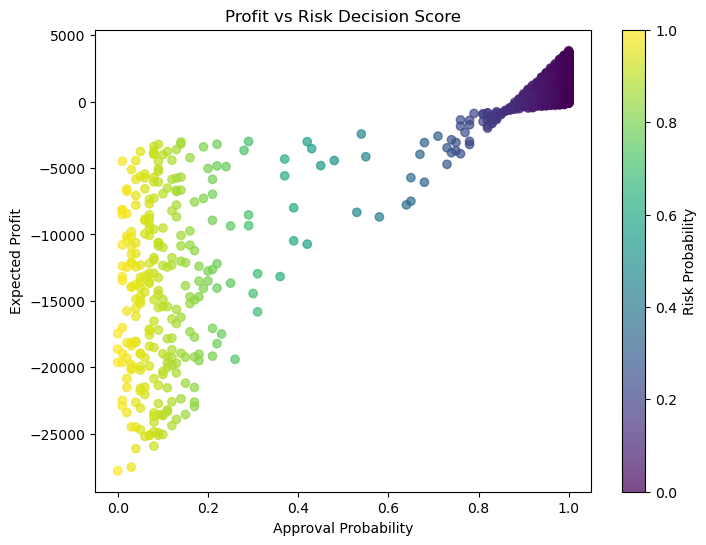

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["approval_probability"],
    df["expected_profit"],
    c=df["risk_probability"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(label="Risk Probability")

plt.xlabel("Approval Probability")
plt.ylabel("Expected Profit")
plt.title("Profit vs Risk Decision Score")

plt.show()

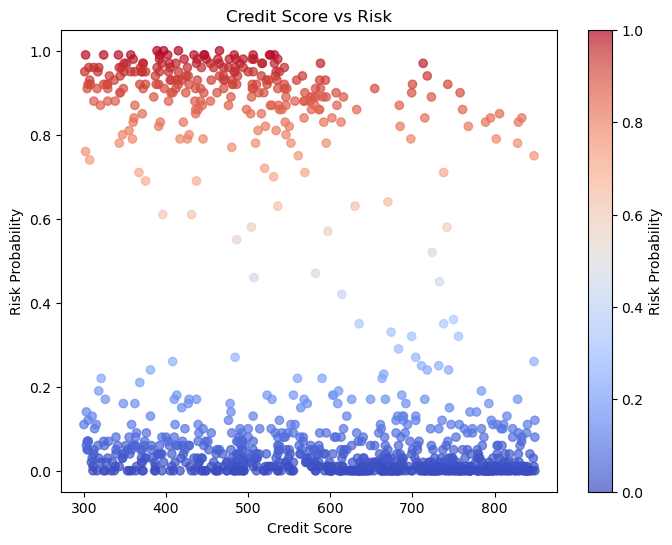

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["credit_score"],
    df["risk_probability"],
    c=df["risk_probability"],
    cmap="coolwarm",
    alpha=0.7
)

plt.colorbar(label="Risk Probability")

plt.xlabel("Credit Score")
plt.ylabel("Risk Probability")
plt.title("Credit Score vs Risk")

plt.show()

In [34]:
total_profit = df["expected_profit"].sum()
total_capital = df["loan_amount"].sum()
return_on_capital = total_profit / total_capital

print("Total Profit:", round(total_profit,2))
print("Return on Capital:", round(return_on_capital,4))

Total Profit: -3014792.42
Return on Capital: -0.1107


In [35]:
thresholds = np.arange(0.2, 0.9, 0.05)

results = []

for t in thresholds:
    approved = df[df["approval_probability"] >= t]
    
    results.append({
        "threshold": t,
        "loans_approved": len(approved),
        "portfolio_profit": approved["expected_profit"].sum()
    })

threshold_df = pd.DataFrame(results)
threshold_df.sort_values("portfolio_profit", ascending=False).head()

,threshold,loans_approved,portfolio_profit
13,0.85,679,830782.9635
12,0.80,707,796870.6130
11,0.75,718,770421.8420
10,0.70,723,752928.8360
9,0.65,728,726605.0095


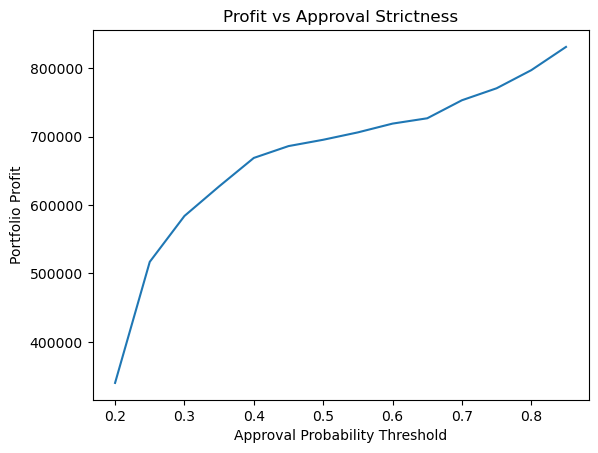

In [36]:
plt.plot(threshold_df["threshold"], threshold_df["portfolio_profit"])
plt.xlabel("Approval Probability Threshold")
plt.ylabel("Portfolio Profit")
plt.title("Profit vs Approval Strictness")
plt.show()

In [38]:
import warnings
warnings.filterwarnings("ignore")

In [39]:
features = df[[
    "annual_income",
    "loan_amount",
    "credit_score",
    "loan_to_income_ratio"
]]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
df["segment"] = kmeans.fit_predict(scaled)

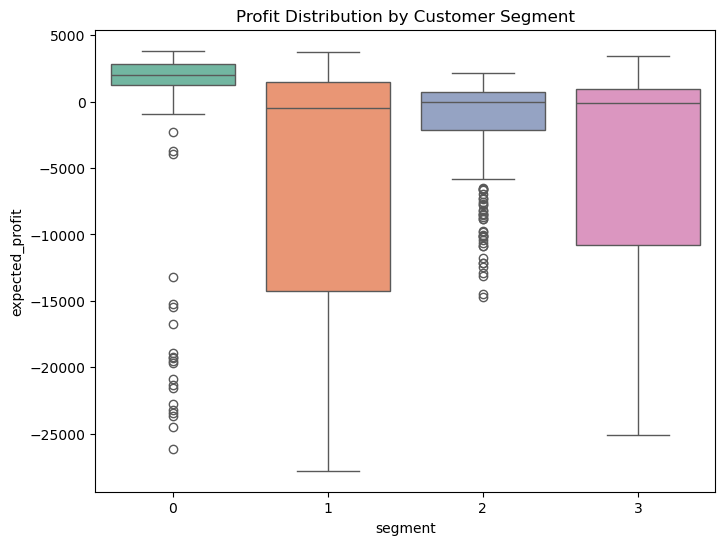

In [48]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="segment",
    y="expected_profit",
    data=df,
    palette="Set2"
)

plt.title("Profit Distribution by Customer Segment")
plt.show()

In [40]:
segment_summary = df.groupby("segment").agg({
    "loan_amount":"mean",
    "risk_probability":"mean",
    "expected_profit":"mean"
}).reset_index()

segment_summary

,segment,loan_amount,risk_probability,expected_profit
0,0,37127.239631,0.096774,179.925403
1,1,36814.986784,0.368590,-6110.280291
2,2,14608.501767,0.237350,-1454.634511
3,3,24531.307692,0.367619,-4597.586236


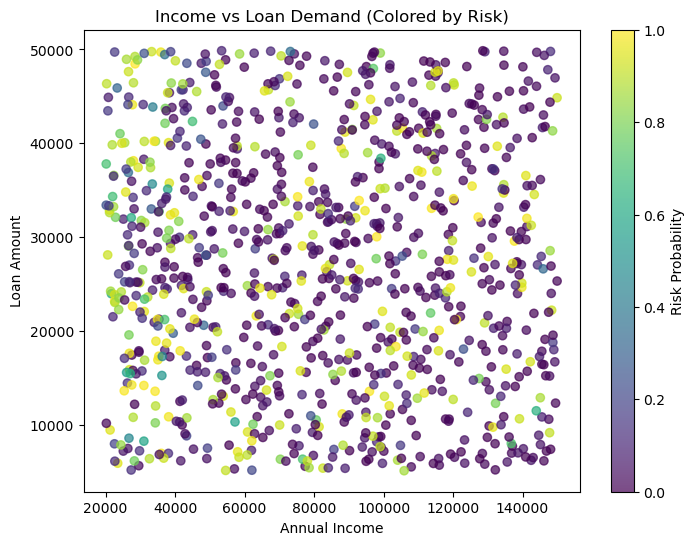

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["annual_income"],
    df["loan_amount"],
    c=df["risk_probability"],   # Business meaningful coloring
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(label="Risk Probability")

plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Demand (Colored by Risk)")

plt.show()

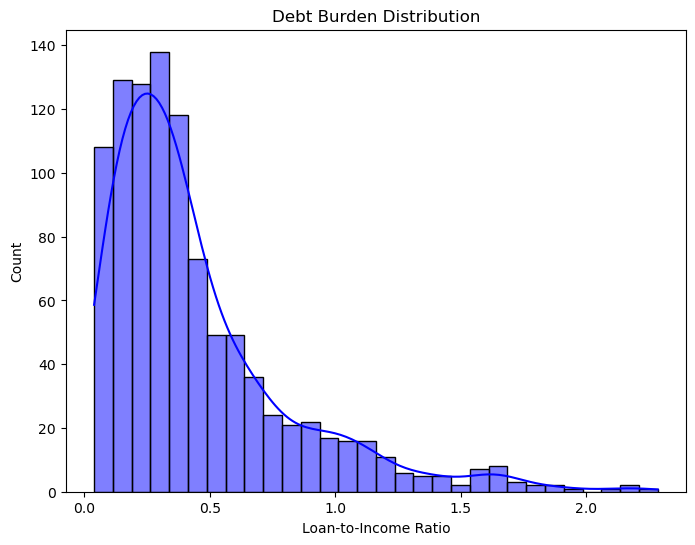

In [54]:
plt.figure(figsize=(8,6))

sns.histplot(
    df["loan_to_income_ratio"],
    bins=30,
    kde=True,
    color="blue"
)

plt.title("Debt Burden Distribution")
plt.xlabel("Loan-to-Income Ratio")
plt.ylabel("Count")

plt.show()

In [41]:
rates = [0.07, 0.09, 0.11, 0.13]

pricing_results = []

for rate in rates:
    revenue = df["loan_amount"] * rate
    
    profit = (
        revenue
        - df["expected_loss"]
        - df["operating_cost"]
    ).sum()
    
    pricing_results.append({
        "interest_rate": rate,
        "total_profit": profit
    })

pricing_df = pd.DataFrame(pricing_results)
pricing_df

,interest_rate,total_profit
0,0.07,-3.559690e+06
1,0.09,-3.014792e+06
2,0.11,-2.469895e+06
3,0.13,-1.924998e+06


In [42]:
risk_shock = [0.00, 0.03, 0.06]

stress_results = []

for shock in risk_shock:
    stressed_loss = (
        (df["risk_probability"] + shock) *
        df["loan_amount"] *
        LOSS_GIVEN_DEFAULT
    )
    
    stressed_profit = (
        df["interest_revenue"]
        - stressed_loss
        - df["operating_cost"]
    ).sum()
    
    stress_results.append({
        "risk_increase": shock,
        "portfolio_profit": stressed_profit
    })

stress_df = pd.DataFrame(stress_results)
stress_df

,risk_increase,portfolio_profit
0,0.00,-3.014792e+06
1,0.03,-3.546067e+06
2,0.06,-4.077342e+06
